# Multilingual Embedding Benchmark — Analysis

Visualising benchmark results from `results/benchmark_results.csv`.

**Task:** cross-lingual TV EPG title matching across English, Russian, and Armenian (HY).

**Hardware:** Apple M2 Max, 32 GB RAM — all models run locally.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

df = pd.read_csv('results/benchmark_results.csv')
df = df.sort_values('cross_lang_mean', ascending=False).reset_index(drop=True)

print(f"Loaded {len(df)} models")
print(f"Columns: {list(df.columns)}")


Loaded 14 models
Columns: ['backend', 'model', 'cross_lang_mean', 'en_ru_mean', 'en_hy_mean', 'ru_hy_mean', 'hy_hy_mean', 'total_time_s', 'time_per_text_s']


In [2]:
# Short display names
NAME_MAP = {
    'intfloat/multilingual-e5-large-instruct': 'e5-large-instruct',
    'intfloat/multilingual-e5-large':          'e5-large',
    'intfloat/multilingual-e5-base':           'e5-base',
    'sentence-transformers/LaBSE':             'LaBSE',
    'Metric-AI/armenian-text-embeddings-1':    'armenian-embeddings-1',
    'intfloat/e5-large-v2':                    'e5-large-v2',
    'BAAI/bge-m3':                             'bge-m3',
    'intfloat/e5-large':                       'e5-large (legacy)',
    'sentence-transformers/paraphrase-multilingual-mpnet-base-v2': 'mpnet-base-v2',
    'sentence-transformers/distiluse-base-multilingual-cased':     'distiluse',
    'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2': 'MiniLM-L12',
    'text-embedding-3-large':                  'text-embedding-3-large',
    'all-MiniLM-L6-v2':                        'all-MiniLM-L6-v2',
}

BACKEND_COLORS = {
    'st':     '#4C72B0',
    'flag':   '#DD8452',
    'openai': '#C44E52',
}
BACKEND_LABELS = {
    'st':     'sentence-transformers',
    'flag':   'FlagEmbedding',
    'openai': 'OpenAI API',
}

df['short'] = df['model'].map(NAME_MAP).fillna(df['model'])
df['label'] = df.apply(
    lambda r: f"{r['short']} [{r['backend']}]" if r['backend'] != 'st' else r['short'],
    axis=1
)
df['color'] = df['backend'].map(BACKEND_COLORS)

df[['label', 'cross_lang_mean', 'hy_hy_mean', 'time_per_text_s']]

,label,cross_lang_mean,hy_hy_mean,time_per_text_s
0,e5-large-instruct,0.8996,0.9754,0.4611
1,e5-large,0.8810,0.9637,0.5189
2,e5-base,0.8764,0.9584,0.4081
3,LaBSE,0.7996,0.9337,0.4674
4,armenian-embeddings-1,0.7975,0.9097,0.3190
5,e5-large-v2,0.7762,0.8331,0.3716
6,bge-m3,0.7665,0.8486,0.4469
7,bge-m3 [flag],0.7665,0.8486,0.2713
8,e5-large (legacy),0.7511,0.8629,0.3868
9,mpnet-base-v2,0.7085,0.7622,0.4244


## Chart 1 — Models ranked by cross-language score

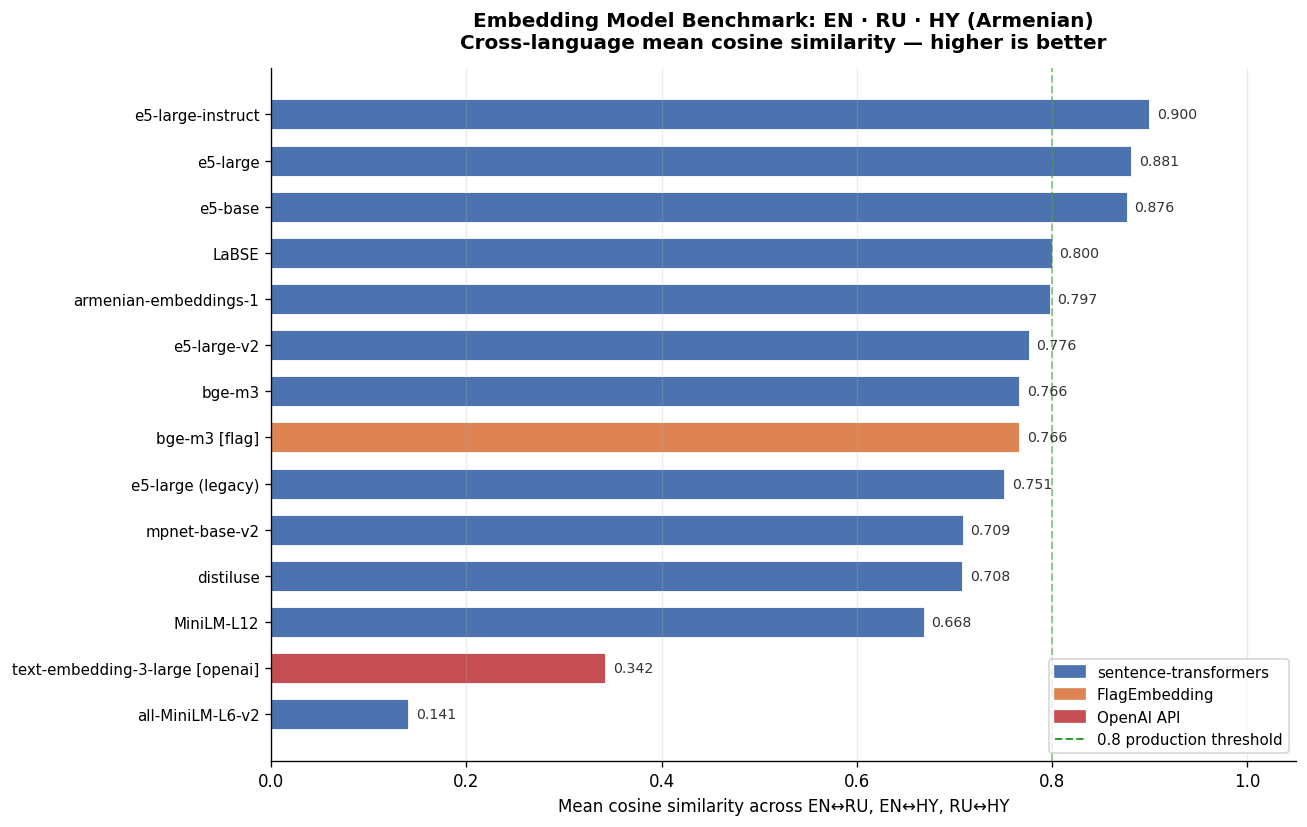

Saved → results/scores_ranked.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    range(len(df)), df['cross_lang_mean'],
    color=df['color'], height=0.65, edgecolor='white', linewidth=0.5
)

ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['label'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Mean cosine similarity across EN↔RU, EN↔HY, RU↔HY', fontsize=10)
ax.set_title(
    'Embedding Model Benchmark: EN · RU · HY (Armenian)\n'
    'Cross-language mean cosine similarity — higher is better',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlim(0, 1.05)
ax.axvline(0.8, color='#2ca02c', linestyle='--', alpha=0.5, linewidth=1.2, label='0.8 production threshold')
ax.grid(axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Value labels
for i, val in enumerate(df['cross_lang_mean']):
    ax.text(val + 0.008, i, f'{val:.3f}', va='center', fontsize=8.5, color='#333')

present_backends = df['backend'].unique()
legend_patches = [
    mpatches.Patch(color=BACKEND_COLORS[k], label=BACKEND_LABELS[k])
    for k in ['st', 'flag', 'openai'] if k in present_backends
]
legend_patches.append(
    plt.Line2D([0], [0], color='#2ca02c', linestyle='--', linewidth=1.2, label='0.8 production threshold')
)
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('results/scores_ranked.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/scores_ranked.png')

## Chart 2 — Accuracy vs Speed trade-off

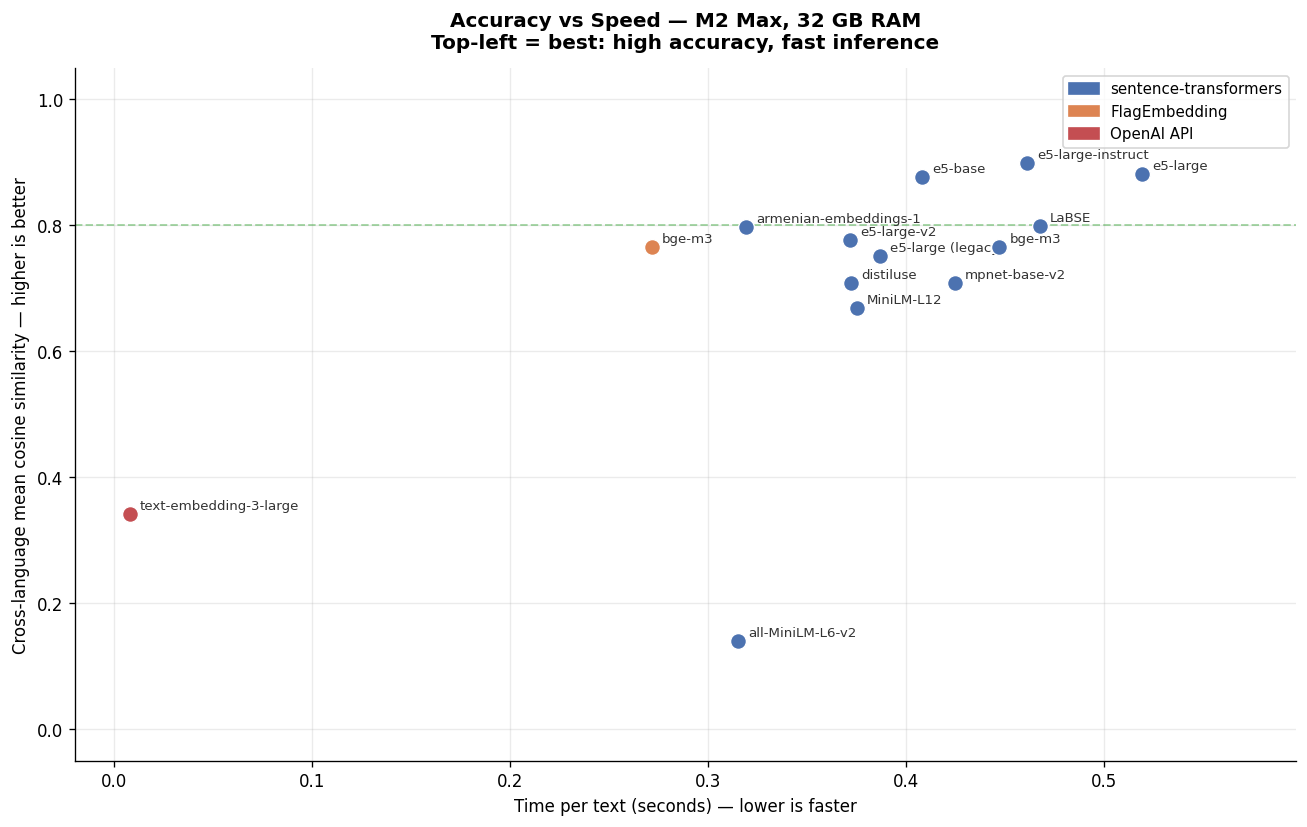

Saved → results/accuracy_vs_speed.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 7))

for _, row in df.iterrows():
    ax.scatter(
        row['time_per_text_s'], row['cross_lang_mean'],
        color=row['color'], s=90, zorder=5,
        edgecolors='white', linewidth=0.8
    )
    ax.annotate(
        row['short'],
        (row['time_per_text_s'], row['cross_lang_mean']),
        fontsize=8, xytext=(6, 3), textcoords='offset points', color='#333'
    )

ax.axhline(0.8, color='#2ca02c', linestyle='--', alpha=0.4, linewidth=1.2, label='0.8 threshold')
ax.set_xlabel('Time per text (seconds) — lower is faster', fontsize=10)
ax.set_ylabel('Cross-language mean cosine similarity — higher is better', fontsize=10)
ax.set_title(
    'Accuracy vs Speed — M2 Max, 32 GB RAM\n'
    'Top-left = best: high accuracy, fast inference',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlim(-0.02, max(df['time_per_text_s']) * 1.15)
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

present_backends = df['backend'].unique()
legend_patches = [
    mpatches.Patch(color=BACKEND_COLORS[k], label=BACKEND_LABELS[k])
    for k in ['st', 'flag', 'openai'] if k in present_backends
]
ax.legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
plt.savefig('results/accuracy_vs_speed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/accuracy_vs_speed.png')

## Chart 3 — Cross-language score vs Armenian consistency (HY↔HY)

Cross-language mean = how well the model aligns the same content across EN/RU/HY.  
HY-HY mean = how consistently the model handles Armenian synonyms within the same language.

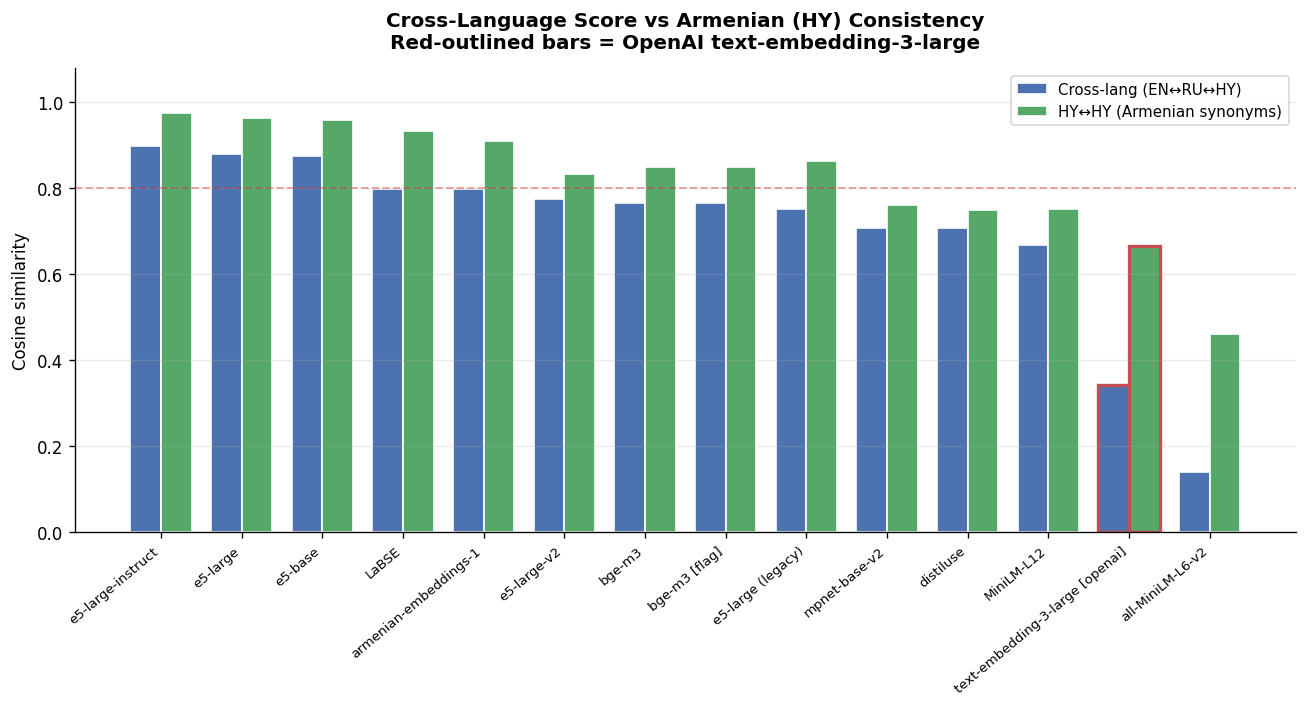

Saved → results/cross_lang_vs_hy.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(df))
w = 0.38

bars1 = ax.bar(x - w/2, df['cross_lang_mean'], width=w, label='Cross-lang (EN↔RU↔HY)', color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + w/2, df['hy_hy_mean'],      width=w, label='HY↔HY (Armenian synonyms)', color='#55A868', edgecolor='white')

# Highlight OpenAI bar if present
openai_idx = df[df['backend'] == 'openai'].index.tolist()
for idx in openai_idx:
    bars1[idx].set_edgecolor('#C44E52')
    bars1[idx].set_linewidth(2)
    bars2[idx].set_edgecolor('#C44E52')
    bars2[idx].set_linewidth(2)

ax.set_xticks(x)
ax.set_xticklabels(df['label'], rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Cosine similarity', fontsize=10)
ax.set_ylim(0, 1.08)
ax.axhline(0.8, color='#d62728', linestyle='--', alpha=0.4, linewidth=1.2)

subtitle = '\nRed-outlined bars = OpenAI text-embedding-3-large' if openai_idx else ''
ax.set_title(
    f'Cross-Language Score vs Armenian (HY) Consistency{subtitle}',
    fontsize=12, fontweight='bold', pad=12
)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('results/cross_lang_vs_hy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/cross_lang_vs_hy.png')

## Chart 4 — Per language-pair heatmap

Breaks down the cross-language score into three language pairs: EN↔RU, EN↔HY, RU↔HY.

This reveals *where* each model fails — e.g. OpenAI collapses specifically on anything involving Armenian (HY).

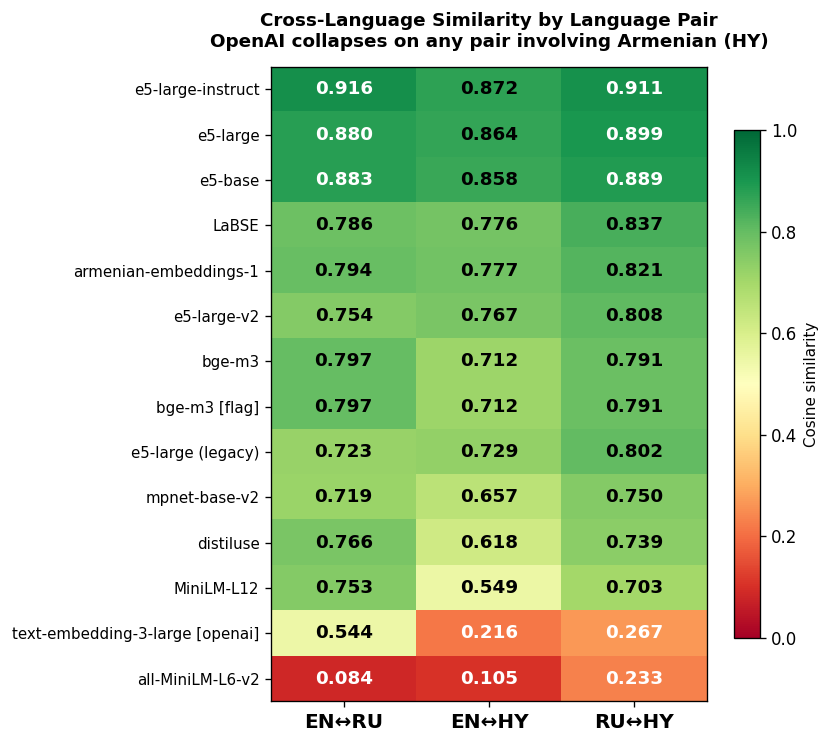

Saved → results/heatmap.png


In [6]:
pair_cols = ['en_ru_mean', 'en_hy_mean', 'ru_hy_mean']
heat_df = df[pair_cols].copy()
heat_df.columns = ['EN↔RU', 'EN↔HY', 'RU↔HY']
heat_df.index = df['label']

fig, ax = plt.subplots(figsize=(7, max(5, len(heat_df) * 0.45)))
im = ax.imshow(heat_df.values, aspect='auto', cmap='RdYlGn', vmin=0.0, vmax=1.0)

ax.set_xticks(range(len(heat_df.columns)))
ax.set_xticklabels(heat_df.columns, fontsize=12, fontweight='bold')
ax.set_yticks(range(len(heat_df.index)))
ax.set_yticklabels(heat_df.index, fontsize=9)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Cosine similarity', fontsize=9)

for i in range(len(heat_df.index)):
    for j in range(len(heat_df.columns)):
        val = heat_df.values[i, j]
        text_color = 'white' if val < 0.35 or val > 0.88 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=text_color)

has_openai = 'openai' in df['backend'].values
subtitle = '\nOpenAI collapses on any pair involving Armenian (HY)' if has_openai else ''
ax.set_title(
    f'Cross-Language Similarity by Language Pair{subtitle}',
    fontsize=11, fontweight='bold', pad=12
)

plt.tight_layout()
plt.savefig('results/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/heatmap.png')

## Key numbers

In [7]:
best = df.iloc[0]
fastest = df.loc[df['time_per_text_s'].idxmin()]
above_threshold = df[df['cross_lang_mean'] >= 0.85]
best_tradeoff = above_threshold.loc[above_threshold['time_per_text_s'].idxmin()]

print(f"Best accuracy:      {best['short']:<35} cross_lang={best['cross_lang_mean']:.4f}  hy_hy={best['hy_hy_mean']:.4f}")
print(f"Best trade-off:     {best_tradeoff['short']:<35} cross_lang={best_tradeoff['cross_lang_mean']:.4f}  time={best_tradeoff['time_per_text_s']:.3f}s/text")
print(f"Fastest inference:  {fastest['short']:<35} time={fastest['time_per_text_s']:.3f}s/text  cross_lang={fastest['cross_lang_mean']:.4f}")

openai_rows = df[df['backend'] == 'openai']
if not openai_rows.empty:
    openai_row = openai_rows.iloc[0]
    print()
    print(f"OpenAI surprise:    {openai_row['short']:<35} cross_lang={openai_row['cross_lang_mean']:.4f}")
    print(f"  → {best['cross_lang_mean'] / openai_row['cross_lang_mean']:.1f}x worse than best model")
    print(f"  → Ranked #{openai_rows.index[0]+1} out of {len(df)} models")

Best accuracy:      e5-large-instruct                   cross_lang=0.8996  hy_hy=0.9754
Best trade-off:     e5-base                             cross_lang=0.8764  time=0.408s/text
Fastest inference:  text-embedding-3-large              time=0.008s/text  cross_lang=0.3424

OpenAI surprise:    text-embedding-3-large              cross_lang=0.3424
  → 2.6x worse than best model
  → Ranked #13 out of 14 models
